# GOAL: Build SARIMAX model

Note: using "previous day" would NOT mean that today is used to predict tomorrow. It means the prediction for today is used to predict tomorrow.

In [1]:
#import statements

#import everything!
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date, datetime, timedelta
from itertools import product
from PreRun import PreRun, PostRun
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX



#path to data
read_path = "../../../../data_ds_project/parquet_cleaned_energy"
#systems
good_systems_list = [4, 10, 33, 36, 50, 51, 1199, 1204, 1283, 1284, 1289, 1332, 4902, 4903]
reader_types = ["meter", "inverter", None]
#systems_cleaned
systems_cleaned = pd.read_csv("../../../data/core/systems_cleaned.csv")

In [2]:
def use_sarimax(df_train, df_ho, p=0, d=0, q=0, P=0, D=0, Q=0, s=0):

    #separate out the exogenous variables
    df_train = df_train.set_index('time')
    df_ho = df_ho.set_index('time')

    # Remove duplicate indices (keep first occurrence)
    df_train = df_train[~df_train.index.duplicated(keep='first')]
    df_ho = df_ho[~df_ho.index.duplicated(keep='first')]

    df_train = df_train.asfreq('h')
    df_ho = df_ho.asfreq('h')

    energy_train = df_train['energy']
    #energy_ho = df_ho['energy']

    exog_train = df_train.drop(columns=['energy'])
    exog_ho = df_ho.drop(columns=['energy'])

    #fit the model
    model_sarimax = SARIMAX(energy_train, exog=exog_train, order=(p,d,q), seasonal_order = (P,D,Q,s)).fit(maxiter=300, disp=False)
    #predict
    y_pred = model_sarimax.forecast(len(df_ho), exog=exog_ho) #should be only 2 steps. hopefully no na's

    #error = PostRun.custom_error(energy_ho, y_pred, 1,2)

    return y_pred#, error

In [17]:
# system_reader_pairs = [(4,None),(10,None), (33, None), (50,None), (51,None), (1283,'inverter'),(1283,'meter')]
# #system_reader_pairs = [(1283,'inverter'),(1283,'meter')]

# # p_choices =[2,3]
# # d_choices = [0,1]
# # q_choices = [0,1,2]

# # P_choices = [0,1,2,3]
# # D_choices = [0]
# # Q_choices = [0,1,2]

# p_choices =[2]
# d_choices = [1]
# q_choices = [0]

# P_choices = [0]
# D_choices = [0]
# Q_choices = [0]


# def process_system_pair(pair, p_choices, d_choices, q_choices, P_choices, D_choices, Q_choices, 
#                         read_path, systems_cleaned):
#     """Process a single system_reader_pair and return results"""
#     system_id = pair[0]
#     reader_type = pair[1]
#     print(f'starting system {system_id}, {reader_type}')

#     prerun = PreRun(system_id = system_id, meter_or_inverter = reader_type, path=read_path, systems_cleaned=systems_cleaned)
#     prerun.load_data()
        
#     prerun.fill_missing_hours()
#     prerun.add_energy_features_only(include_last_year = True, remove_last_year_nans=True)
#     print(prerun.amended_data)

#     prerun.add_weather_features_only()

#     all_data=prerun.amended_data

#     prerun.good_end_days_naive(10)
#     prerun.tts_of_data_using_end_days()

#     system_recorded_max = prerun.data['energy'].max()

#     # Build results as a dictionary to avoid pandas reindexing issues
#     all_errors_dict = {}
    
#     for p,d,q,P,D,Q in product(p_choices,d_choices,q_choices,P_choices,D_choices,Q_choices):
#         print(f'     starting p={p}, d={d}, q={q}, P={P}, D={D}, Q={Q}')
#         errors=[]
#         for pred_date in prerun.train_dates['date']:
#             #print(type(date))

        
#             train_data = all_data.loc[(all_data['time'] < pred_date - timedelta(days=1)) &
#                                     (all_data['time'] >= pred_date - timedelta(days=10))].reset_index(drop=True)
#             ho_data = all_data[(all_data['time'] >= pred_date - timedelta(days=1)) 
#                                 & (all_data['time'] <= pred_date)].reset_index(drop=True)

#             y_pred = use_sarimax(train_data, ho_data, p=p, d=d, q=q, P=P, s=0, D=D, Q=Q)
#             energy_ho = ho_data['energy']

#             #make sure value between 0 and highest observed max
#             y_pred = np.clip(y_pred, 0, system_recorded_max)
#             #make sure that if it's not sunlight hours and irradiance = 0, then energy = 0
#             darkness_mask = (~((ho_data['proportion_daytime']==0) & (ho_data['global_tilted_irradiance']==0))).astype(int) # = 0 when both sunlight prop and irr are 0
#             y_pred = y_pred*np.array(darkness_mask)

#             error = PostRun.custom_error(energy_ho, y_pred, 1,2)

#             errors.append(error)

#         # Store error list in dictionary (avoids reindexing issues)
#         all_errors_dict[f'{p},{d},{q},{P},{D},{Q}'] = errors

#     # Convert dictionary to DataFrame at the end (single operation)
#     all_errors_df = pd.DataFrame(all_errors_dict)

#     # # Old code (commented out):
#     # all_errors_df = pd.DataFrame()
#     # 
#     # for p,d,q,P,D,Q in product(p_choices,d_choices,q_choices,P_choices,D_choices,Q_choices):
#     #     print(f'     starting p={p}, d={d}, q={q}, P={P}, D={D}, Q={Q}')
#     #     errors=[]
#     #     for pred_date in prerun.train_dates['date']:
#     #         train_data = all_data.loc[(all_data['time'] < pred_date - timedelta(days=1)) &
#     #                                 (all_data['time'] >= pred_date - timedelta(days=10))].reset_index(drop=True)
#     #         ho_data = all_data[(all_data['time'] >= pred_date - timedelta(days=1)) 
#     #                             & (all_data['time'] <= pred_date)].reset_index(drop=True)
#     #         y_pred = use_sarimax(train_data, ho_data, p=p, d=d, q=q, P=P, s=24, D=D, Q=Q)
#     #         energy_ho = ho_data['energy']
#     #         y_pred = np.clip(y_pred, 0, system_recorded_max)
#     #         darkness_mask = (~((ho_data['proportion_daytime']==0) & (ho_data['global_tilted_irradiance']==0))).astype(int)
#     #         y_pred = y_pred*np.array(darkness_mask)
#     #         error = PostRun.custom_error(energy_ho, y_pred, 1,2)
#     #         errors.append(error)
#     #     all_errors_df[f'{p},{d},{q},{P},{D},{Q}'] = pd.Series(errors)

#     # Save results for this pair
#     output_path = Path(f'sarimax_errors/{system_id}_{reader_type}_sarimax_errors.csv')
#     output_path.parent.mkdir(parents=True, exist_ok=True)
#     all_errors_df.to_csv(output_path)
    
#     return (system_id, reader_type, all_errors_df)


# # # Serial execution (original code, commented out)
# # for pair in system_reader_pairs:
# #     system_id = pair[0]
# #     reader_type = pair[1]
# #     print(f'starting system {system_id}, {reader_type}')

# #     prerun = PreRun(system_id = system_id, meter_or_inverter = reader_type, path=read_path, systems_cleaned=systems_cleaned)
# #     prerun.load_data()
# #         
# #     prerun.fill_missing_hours()
# #     prerun.add_energy_features_only(include_last_year = True, remove_last_year_nans=True, highest_fourier_term_hour=2)
# #     print(prerun.amended_data)

# #     prerun.add_weather_features_only()

# #     all_data=prerun.amended_data

# #     prerun.good_end_days_naive(10)
# #     prerun.tts_of_data_using_end_days()

# #     system_recorded_max = prerun.data['energy'].max()

# #     all_errors_df = pd.DataFrame()
# #     
# #     for p,d,q,P,D,Q in product(p_choices,d_choices,q_choices,P_choices,D_choices,Q_choices):
# #         print(f'     starting p={p}, d={d}, q={q}, P={P}, D={D}, Q={Q}')
# #         errors=[]
# #         for pred_date in prerun.train_dates['date']:
# #             #print(type(date))

# #         
# #             train_data = all_data.loc[(all_data['time'] < pred_date - timedelta(days=1)) &
# #                                     (all_data['time'] >= pred_date - timedelta(days=10))].reset_index(drop=True)
# #             ho_data = all_data[(all_data['time'] >= pred_date - timedelta(days=1)) 
# #                                 & (all_data['time'] <= pred_date)].reset_index(drop=True)

# #             y_pred = use_sarimax(train_data, ho_data, p=p, d=d, q=q, P=P, s=0, D=D, Q=Q)
# #             energy_ho = ho_data['energy']
# #             error = PostRun.custom_error(energy_ho, y_pred, 1,2)

# #             errors.append(error)

# #         all_errors_df[f'{p},{d},{q},{P},{D},{Q}'] = pd.Series(errors)

# # all_errors_df.to_csv(f'sarimax_errors/{system_id}_{reader_type}_sarimax_errors')


# # Parallel execution
# results = Parallel(n_jobs=-1)(
#     delayed(process_system_pair)(
#         pair, 
#         p_choices, 
#         d_choices, 
#         q_choices, 
#         P_choices, 
#         D_choices, 
#         Q_choices, 
#         read_path, 
#         systems_cleaned
#     ) 
#     for pair in system_reader_pairs
# )

# print("\nAll processing complete!")
# for system_id, reader_type, errors_df in results:
#     print(f'Completed: system {system_id}, {reader_type}')

In [ ]:
system_reader_pairs = [(4,None),(10,None), (33, None), (50,None), (51,None), (1283,'inverter'),(1283,'meter')]

p_choices =[2,3]
d_choices = [0,1]
q_choices = [0,1]

for pair in system_reader_pairs:
    system_id = pair[0]
    reader_type = pair[1]
    print(f'starting system {system_id}, {reader_type}')

    prerun = PreRun(system_id = system_id, meter_or_inverter = reader_type, path=read_path, systems_cleaned=systems_cleaned)
    prerun.load_data()
        
    prerun.fill_missing_hours()
    prerun.add_energy_features_only(include_last_year = True, remove_last_year_nans=True, highest_fourier_term_hour=2)
    #print(prerun.amended_data)

    prerun.add_weather_features_only()

    all_data=prerun.amended_data

    prerun.good_end_days_naive(10)
    prerun.tts_of_data_using_end_days()

    system_recorded_max = prerun.data['energy'].max()

    #get all train/ho data sets ONCE so it's not redone for each (p,d,q)
    splits = []

    for pred_date in prerun.train_dates['date']:
        train_mask = (
            (all_data['time'] < pred_date - timedelta(days=1)) &
            (all_data['time'] >= pred_date - timedelta(days=10))
        )
        ho_mask = (
            (all_data['time'] >= pred_date - timedelta(days=1)) &
            (all_data['time'] <= pred_date)
        )

        train_data = all_data.loc[train_mask].reset_index(drop=True)
        ho_data = all_data.loc[ho_mask].reset_index(drop=True)

        splits.append((pred_date, train_data, ho_data))
    
    results_dict = {}

    for p,d,q in product(p_choices,d_choices,q_choices):
        print(f'     starting p={p}, d={d}, q={q}')
        errors=[]
        
        for pred_date, train_data, ho_data in splits:
            try: 
                y_pred = use_sarimax(train_data, ho_data, p=p, d=d, q=q)

                #make sure value between 0 and highest observed max
                y_pred = np.clip(y_pred, 0, system_recorded_max)
                #make sure that if it's not sunlight hours and irradiance = 0, then energy = 0
                darkness_mask = (~((ho_data['proportion_daytime']==0) & (ho_data['global_tilted_irradiance']==0))).astype(int) # = 0 when both sublight prop and irr are 0
                y_pred = y_pred*np.array(darkness_mask)

                energy_ho = ho_data['energy']
                error = PostRun.custom_error(energy_ho.iloc[24:], y_pred.iloc[24:], 1,2)
            except Exception as e:
                print(f'FAILED: (p,d,q) = {p,d,q} --> {type(e).__name__}: {e}')
                error = -1
                

            errors.append(error)

        results_dict[f"{p},{d},{q}"] = errors
    all_errors_df = pd.DataFrame(results_dict)
    all_errors_df.to_csv(f'sarimax_errors/{system_id}_{reader_type}_sarimax_errors.csv', index = False)

starting system 4, None
     starting p=2, d=0, q=0


c:\Users\hjpha\anaconda3\envs\erdos_ds_environment\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\hjpha\anaconda3\envs\erdos_ds_environment\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\hjpha\anaconda3\envs\erdos_ds_environment\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\hjpha\anaconda3\envs\erdos_ds_environment\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed t

     starting p=2, d=0, q=1


c:\Users\hjpha\anaconda3\envs\erdos_ds_environment\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\hjpha\anaconda3\envs\erdos_ds_environment\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\hjpha\anaconda3\envs\erdos_ds_environment\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\hjpha\anaconda3\envs\erdos_ds_environment\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-inv

     starting p=2, d=1, q=0


...

c:\Users\hjpha\anaconda3\envs\erdos_ds_environment\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\hjpha\anaconda3\envs\erdos_ds_environment\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\hjpha\anaconda3\envs\erdos_ds_environment\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\hjpha\anaconda3\envs\erdos_ds_environment\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed t

     starting p=3, d=1, q=0


c:\Users\hjpha\anaconda3\envs\erdos_ds_environment\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\hjpha\anaconda3\envs\erdos_ds_environment\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\hjpha\anaconda3\envs\erdos_ds_environment\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\hjpha\anaconda3\envs\erdos_ds_environment\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed t

     starting p=3, d=1, q=1


c:\Users\hjpha\anaconda3\envs\erdos_ds_environment\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\hjpha\anaconda3\envs\erdos_ds_environment\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\hjpha\anaconda3\envs\erdos_ds_environment\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\hjpha\anaconda3\envs\erdos_ds_environment\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed t

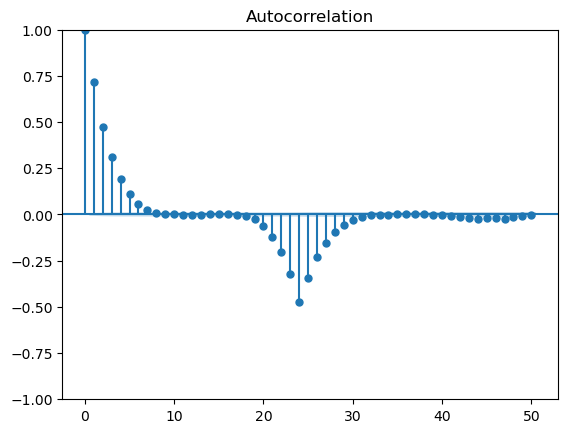

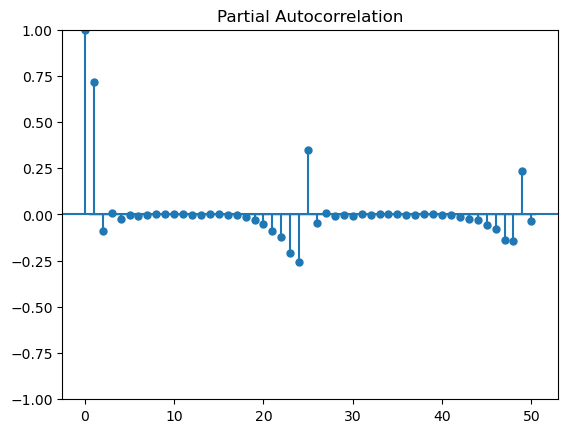

In [9]:
#some quick eda
system_id = 4
reader_type = None

prerun = PreRun(system_id = system_id, meter_or_inverter = reader_type, path=read_path, systems_cleaned=systems_cleaned)
prerun.load_data()
prerun.fill_missing_hours()
prerun.add_energy_features_only(include_hour_cyclic=True)
prerun.add_weather_features_only()

all_data = prerun.amended_data
end_days = prerun.good_end_days_naive(7)

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
y_deseason = all_data['energy'].diff(24).dropna()
plot_acf(y_deseason)
plt.show()

plot_pacf(y_deseason)
plt.show()

